# Exposure-bias probe — 7-7-offline-aug

The **7-7-offline-aug** Arioso flow-matching model has an excellent *on-line* velocity fit
(~0.12–0.15 MSE mid/late t, ~0.38 near t=0), but its *off-path* velocity error explodes toward
t=1 (~5.4 at t=0.95). A solver step-sweep showed reconstruction flat-to-worse at higher NFE,
which **rules out discretization**.

**Hypothesis:** the field has no restoring behavior off the OT line in the *back half*, and the
free-running sampler accumulates drift exactly there — classic **exposure bias**.

This notebook instruments **standard free-running generation** (no retrain, no substituted
field) and logs, per integration step, three velocities at the sampler's *actual* drifted state
`(x_t_gen, t)`:

- **v1** — `model(x_t_gen, x0, t)`: what the model *actually does* at the drifted position. This
  is the same forward that advances the sampler.
- **v2** — `(x1 - x_t_gen)/(1-t)`: the **ideal recovery direction** — the constant velocity from
  the current (drifted) point that would still land exactly on the target endpoint at t=1. This
  is the **DAgger expert label**: what an oracle would tell the sampler to do from where it
  actually is.
- **v3** — `model(x_t_true, x0, t)`: the model's *on-line* behavior at the matched t, evaluated
  at the clean OT-path point `x_t_true`. The gap `v1 − v3` isolates how much the drift itself
  changes the model's output (**divergence** from the on-line regime).

**Three outcome branches** (interpreted at the end):

- **(a) exposure bias confirmed** — drift grows monotonically toward t=1, recovery error blows
  up late, and restoring cosine → 0 / negative late. ⇒ schedule-reshape retrain justified;
  concentrate augmentation in the back half.
- **(b) not exposure bias** — recovery error bounded / cosine positive throughout. ⇒ the ceiling
  isn't exposure bias; pivot to a masked-vs-unmasked-metric (silence-floor) check before retrain.
- **(c) two-scale mismatch** — drift never reaches the off-path probe scale. ⇒ the off-path
  metric and schedule std need recalibrating to the real drift.

> Run from the **project root** so the `Arioso` / `DataSynthesizer` / `common` packages import.
> No vocoder is loaded anywhere — this notebook never makes audio.

In [ ]:
%matplotlib inline
import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Run from the project root so Arioso / DataSynthesizer / common import. When executed via
# nbconvert (whose cwd is the notebook's own dir), hop up to the parent project root.
if not os.path.isdir("Arioso") and os.path.isdir(os.path.join("..", "Arioso")):
    os.chdir("..")
_root = os.path.abspath(os.getcwd())
if _root not in sys.path:
    sys.path.insert(0, _root)

from DataSynthesizer.config import DEFAULT_OUT
from Arioso.config import CKPT_DIR, PRIOR_MEL_DIR, cfg_from_dict
from Arioso.model import AriosoModel
from Arioso.splits import make_split
from Arioso.clips import enumerate_clips
from Arioso.infer import generate_mel
from Arioso.train import OFFPATH_EVAL_STD          # = 2.7, the off-path robustness probe std

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = DEFAULT_OUT                                # 'data' — the dataset root
CKPT = os.path.join(CKPT_DIR, "7-9-adr", "checkpoint_final.pt")
WEIGHTS = "ema"                                      # inference uses the EMA weights
SEED = 0                                             # fixed so the clip draw is reproducible
N_CLIPS = 16                                         # one clip per held-out recording
SOLVER = "euler"                                     # Euler only (see probe_clip assert)
STEPS = 16                                           # dt = 1/16; t visits i/16 for i=0..15
DRIFT_CAL = 1.34                                     # empirical drift calibration (~1.34 * t)
# The RMSE-1.634 worst clip from validation_test.ipynb (853 frames, no truncation needed).
PINNED_WORST = ("Kayser_Op20-04_MikeChau_Na8vEEFEu2I-0004-0170", 10200, 11053)

print(f"device={DEVICE}  ckpt={CKPT}")
print(f"solver={SOLVER}  steps={STEPS}  seed={SEED}  n_clips={N_CLIPS}")
print(f"OFFPATH_EVAL_STD={OFFPATH_EVAL_STD}  DRIFT_CAL={DRIFT_CAL}")

device=cuda  ckpt=Arioso/models\lr_anneal\checkpoint_final.pt
solver=euler  steps=16  seed=0  n_clips=16
OFFPATH_EVAL_STD=2.7  DRIFT_CAL=1.34


## Load the final checkpoint

Load the checkpoint first, then build the model from **its** embedded config (`cfg_from_dict`),
exactly as the sibling notebooks do. This checkpoint is the **unconditioned** ablation
(`cfg.conditioning == ()`), so `cond=None` everywhere — we assert that below.

In [2]:
ckpt = torch.load(CKPT, map_location=DEVICE)
cfg = cfg_from_dict(ckpt.get("cfg") or {})
model = AriosoModel(cfg).to(DEVICE)
model.load_state_dict(ckpt[WEIGHTS])
model.eval()

# This probe assumes an UNCONDITIONED model: cond=None throughout.
assert len(cfg.conditioning) == 0, f"expected unconditioned model, got conditioning={cfg.conditioning}"

SIGMA = cfg.sigma                                    # 1e-4 — matches Arioso/cfm.py:interpolate
print(f"loaded step {ckpt.get('step', '?')}  |  {model.num_params() / 1e6:.1f}M params  |  weights='{WEIGHTS}'")
print(f"conditioning={cfg.conditioning}  (unconditioned)  |  sigma={SIGMA}")
print(f"chunk_frames={cfg.chunk_frames}  n_mels={cfg.n_mels}  sr={cfg.sr}  hop={cfg.hop}")

c:\Users\archi\miniconda3\envs\ai-violin\Lib\site-packages\torch\_utils.py:99: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  untyped_storage = torch.UntypedStorage(self.size(), device=device)


loaded step 20000  |  34.1M params  |  weights='ema'
conditioning=()  (unconditioned)  |  sigma=0.0001
chunk_frames=860  n_mels=128  sr=44100  hop=512


## Select the probe clips

One clip per held-out **recording** (distinct performances, not overlapping windows of one),
using the exact `solver_sweep.ipynb` selection pattern with `SEED=0`. Each clip is truncated to
`cfg.chunk_frames` (860) so `generate_mel` stays single-chunk and the probe's inline Euler loop
matches `integrate()` exactly.

Then we **append the pinned worst clip** (RMSE-1.634 from `validation_test.ipynb`) — unless that
exact recording was already drawn, in which case it's already covered.

In [3]:
rng = random.Random(SEED)

split = make_split(OUT_DIR, cfg)
val_clips = enumerate_clips(OUT_DIR, split["val"], cfg)
print(f"val recordings: {len(split['val'])}   val clips: {len(val_clips)}")

by_recording = {}
for c in val_clips:
    by_recording.setdefault(c.basename, []).append(c)

chosen_recordings = rng.sample(sorted(by_recording), k=min(N_CLIPS, len(by_recording)))
examples = [rng.choice(by_recording[b]) for b in chosen_recordings]

# Each clip is a (basename, start, end) triple; truncate to chunk_frames (single-chunk path).
clips = []
for c in examples:
    end = min(c.end, c.start + cfg.chunk_frames)
    clips.append((c.basename, c.start, end))

# Append the pinned worst clip, unless its recording was already drawn.
pin_name, pin_start, pin_end = PINNED_WORST
pin_end = min(pin_end, pin_start + cfg.chunk_frames)                 # 853 frames — no truncation
already_drawn = any(name == pin_name for name, _, _ in clips)
pinned_index = None
if already_drawn:
    print(f"pinned worst recording {pin_name!r} was already drawn — not re-appending")
else:
    clips.append((pin_name, pin_start, pin_end))
    pinned_index = len(clips) - 1

print(f"\n{len(clips)} probe clips (pinned worst is index {pinned_index}):")
for i, (name, start, end) in enumerate(clips):
    dur = (end - start) / cfg.sr * cfg.hop
    tag = "  <-- PINNED WORST" if i == pinned_index else ""
    print(f"  [{i}] {name}  frames {start}:{end}  ({end - start} fr, ~{dur:.1f}s){tag}")

val recordings: 74   val clips: 56029

17 probe clips (pinned worst is index 16):
  [0] Wohlfahrt_Op45-39_BernardChevalier_ztj_dBul8fU-0000-0115  frames 1395:2255  (860 fr, ~10.0s)
  [1] Wohlfahrt_Op45-39_BrianClement_QU4_IrlYPhs-0000-0110  frames 7349:8204  (855 fr, ~9.9s)
  [2] Kayser_Op20-04_JPRafferty_49hp2uSHLqI-0000-0097  frames 2585:3442  (857 fr, ~9.9s)
  [3] Paganini_Op01-14_AlicanSuner_Yr7oE4WcVCw-0000-0147  frames 7632:8477  (845 fr, ~9.8s)
  [4] Wohlfahrt_Op45-46_ZYZ_eVpAqTyJBQw-0003-0129  frames 3199:4051  (852 fr, ~9.9s)
  [5] Wohlfahrt_Op45-46_BrianClement_QPH5nASSl0A-0000-0103  frames 5296:6152  (856 fr, ~9.9s)
  [6] Wohlfahrt_Op45-39_BochanKang_VnMeLQx-Fgo-0676-0728  frames 908:1762  (854 fr, ~9.9s)
  [7] Wohlfahrt_Op45-28_BrianClement_NBnRfbFM_Rg-0000-0052  frames 287:1144  (857 fr, ~9.9s)
  [8] Wohlfahrt_Op45-46_BochanKang_Y4VtL_XAMHs-0125-0232  frames 7862:8293  (431 fr, ~5.0s)
  [9] Wohlfahrt_Op45-38_JPRafferty_UUbVDNNc6NM-0000-0100  frames 7168:7962  (794 fr, ~9.2

## Probe machinery

`load_clip_mels` mirrors `validation_test.ipynb`. `rms` is a **per-element RMS** over the whole
128×T clip — `sqrt(mean(a**2))` — comparable to the 1.34·t drift calibration and to
reconstruction RMSE (never a summed L2).

`probe_clip` replicates `integrate()`'s Euler loop **inline** (it does not call `integrate()` /
`generate_mel()`), so we can read the three velocities at each step. Per step it computes:

- **drift** `= rms(x_t_gen − x_t_true)` — how far the sampler has wandered off the OT line.
- **recovery_err** `= rms(v1 − v2)` — how wrong the model's velocity is vs the DAgger expert.
- **restoring_cos** `= cos(v1, v2)` — is the model even *pointing* toward recovery?
- **divergence** `= rms(v1 − v3)` — how much the drift alone changes the model's output.
- error budget — per-step proxy `drift*dt` and cumulative `cumsum(recovery_err)*dt`.

In [4]:
prior_dir = os.path.join(OUT_DIR, PRIOR_MEL_DIR)
target_dir = os.path.join(OUT_DIR, "target_mel")


def load_clip_mels(basename, start, end):
    """Prior (x0) and GT (x1) mel slices for a clip, each [128, T] float32."""
    x0 = np.load(os.path.join(prior_dir, basename + ".npy"), mmap_mode="r")[:, start:end]
    x1 = np.load(os.path.join(target_dir, basename + ".npy"), mmap_mode="r")[:, start:end]
    return np.ascontiguousarray(x0, dtype=np.float32), np.ascontiguousarray(x1, dtype=np.float32)


def rms(a):
    """Per-element RMS over the whole clip: sqrt(mean(a**2)). NEVER a summed L2."""
    return float(np.sqrt(np.mean(np.asarray(a, dtype=np.float64) ** 2)))


def cos_flat(a, b):
    """Cosine similarity of two tensors flattened to 1-D."""
    af, bf = a.flatten(), b.flatten()
    denom = float(torch.linalg.norm(af) * torch.linalg.norm(bf))
    return float(torch.dot(af, bf) / denom) if denom > 0 else 0.0


@torch.no_grad()
def probe_clip(x0_np, x1_np, keep_fields=False):
    """Free-running Euler generation with per-step exposure-bias instrumentation.

    Replicates Arioso/infer.py:integrate()'s loop INLINE (x <- x + dt*v1) so the three velocity
    vectors can be read at each step. Euler only: the 3-vector decomposition is defined at a
    single (x_t, t); Heun/midpoint inner evals sit at shifted states (a k1-as-v1 fallback is
    possible but not implemented here).
    """
    assert SOLVER == "euler", "probe_clip is Euler-only (see docstring)"
    T = x0_np.shape[1]
    x0 = torch.from_numpy(x0_np[None]).to(DEVICE)                   # [1, 128, T]
    x1 = torch.from_numpy(x1_np[None]).to(DEVICE)
    x = x0.clone()                                                 # init x = x0 (t=0)
    dt = 1.0 / STEPS

    drift = np.zeros(STEPS); recovery_err = np.zeros(STEPS)
    restoring_cos = np.zeros(STEPS); divergence = np.zeros(STEPS)
    fields = [] if keep_fields else None

    for i in range(STEPS):
        t = i / STEPS                                              # 0, 1/16, ..., 15/16
        tt = torch.full((1,), float(t), device=DEVICE)

        # v1: what the model actually does at the sampler's drifted state (advances the sampler).
        v1 = model(x, x0, tt, cond=None)

        # v2: ideal recovery / DAgger expert label. Plain (x1 - x_t)/(1-t); with t<=15/16,
        # (1-t) >= 1/16 so no blow-up. (A sigma-corrected variant exists — v_target-style — but
        # the plain form is the spec here.)
        v2 = (x1 - x) / (1.0 - t)

        # v3: on-line behavior at matched t, evaluated at the CLEAN OT-path point x_t_true.
        # x_t_true matches Arioso/cfm.py:interpolate exactly.
        x_t_true = (1.0 - (1.0 - SIGMA) * t) * x0 + t * x1
        v3 = model(x_t_true, x0, tt, cond=None)

        d = (x - x_t_true).cpu().numpy()
        drift[i] = rms(d)
        recovery_err[i] = rms((v1 - v2).cpu().numpy())
        restoring_cos[i] = cos_flat(v1, v2)
        divergence[i] = rms((v1 - v3).cpu().numpy())
        if keep_fields:
            fields.append(np.abs((v1 - v2)[0].cpu().numpy()))      # [128, T]

        # At t=0: x_t_true = x0 and x = x0, so drift and divergence must be ~0.
        if i == 0:
            assert drift[i] < 1e-4, f"drift at t=0 = {drift[i]} (expected ~0)"
            assert divergence[i] < 1e-4, f"divergence at t=0 = {divergence[i]} (expected ~0)"

        # Advance the sampler with the SAME v1 (Euler step).
        x = x + dt * v1

    out_mel = x[0].cpu().numpy()
    x_final = out_mel
    result = {
        "drift": drift, "recovery_err": recovery_err,
        "restoring_cos": restoring_cos, "divergence": divergence,
        "drift_budget": drift * dt,
        "recovery_cum": np.cumsum(recovery_err) * dt,
        "final_rmse": float(np.sqrt(np.mean((x_final - x1_np) ** 2))),
        "final_mae": float(np.mean(np.abs(x_final - x1_np))),
        "out_mel": out_mel,
    }
    if keep_fields:
        result["fields"] = np.stack(fields)                        # [STEPS, 128, T]
    return result

## Run the probe over all clips

Two forwards per step (v1 + v3), `STEPS` steps, `len(clips)` clips. Per-clip final RMSE/MAE is
printed as it goes.

In [5]:
import time
t_start = time.time()

results = []
for i, (name, start, end) in enumerate(clips):
    x0, x1 = load_clip_mels(name, start, end)
    r = probe_clip(x0, x1)
    r.update({"basename": name, "start": start, "end": end,
              "is_pinned": (i == pinned_index)})
    results.append(r)
    tag = "  <-- PINNED WORST" if i == pinned_index else ""
    print(f"[{i + 1}/{len(clips)}] {name}  final RMSE {r['final_rmse']:.4f}  MAE {r['final_mae']:.4f}{tag}")

elapsed = time.time() - t_start
print(f"\nprobed {len(results)} clips in {elapsed:.1f}s")

[1/17] Wohlfahrt_Op45-39_BernardChevalier_ztj_dBul8fU-0000-0115  final RMSE 1.1550  MAE 0.9009
[2/17] Wohlfahrt_Op45-39_BrianClement_QU4_IrlYPhs-0000-0110  final RMSE 1.2935  MAE 0.9438
[3/17] Kayser_Op20-04_JPRafferty_49hp2uSHLqI-0000-0097  final RMSE 1.0739  MAE 0.8113
[4/17] Paganini_Op01-14_AlicanSuner_Yr7oE4WcVCw-0000-0147  final RMSE 1.1999  MAE 0.9504
[5/17] Wohlfahrt_Op45-46_ZYZ_eVpAqTyJBQw-0003-0129  final RMSE 0.9811  MAE 0.7687
[6/17] Wohlfahrt_Op45-46_BrianClement_QPH5nASSl0A-0000-0103  final RMSE 1.1265  MAE 0.8207
[7/17] Wohlfahrt_Op45-39_BochanKang_VnMeLQx-Fgo-0676-0728  final RMSE 1.4423  MAE 1.1168
[8/17] Wohlfahrt_Op45-28_BrianClement_NBnRfbFM_Rg-0000-0052  final RMSE 1.2562  MAE 0.9982
[9/17] Wohlfahrt_Op45-46_BochanKang_Y4VtL_XAMHs-0125-0232  final RMSE 2.4028  MAE 1.9143
[10/17] Wohlfahrt_Op45-38_JPRafferty_UUbVDNNc6NM-0000-0100  final RMSE 1.1920  MAE 0.9274
[11/17] Paganini_Op01-06-a_SalvatoreAccardo_56vQsMqrfYI-0000-0273  final RMSE 1.0958  MAE 0.8582
[12/17] Pa

### Sampler-equivalence check

`probe_clip` advances with the same `x <- x + dt*v1` Euler step as `integrate()`. Since every
clip is ≤ `chunk_frames`, `generate_mel` takes the single-chunk path — the identical code path.
We assert the two final mels agree to `atol=1e-4` on one clip.

In [6]:
chk_name, chk_start, chk_end = clips[0]
x0_chk, x1_chk = load_clip_mels(chk_name, chk_start, chk_end)
probe_out = probe_clip(x0_chk, x1_chk)["out_mel"]
gen_out = generate_mel(model, x0_chk, cfg, DEVICE, solver="euler", steps=STEPS)
max_abs = float(np.max(np.abs(probe_out - gen_out)))
assert np.allclose(probe_out, gen_out, atol=1e-4), f"probe vs generate_mel differ (max abs {max_abs:.2e})"
print(f"sampler-equivalence OK: max abs diff {max_abs:.2e} (< 1e-4) on {chk_name}")

sampler-equivalence OK: max abs diff 0.00e+00 (< 1e-4) on Wohlfahrt_Op45-39_BernardChevalier_ztj_dBul8fU-0000-0115


## Decile aggregation

`t_grid = arange(STEPS)/STEPS`; each step is binned into a t-decile. With `STEPS=16`, deciles
hold **1–2 steps each**. The `summary` table reports mean±std of each of the four scalars over
all (clip, step) pairs in that decile.

In [7]:
t_grid = np.arange(STEPS) / STEPS
decile = np.clip((t_grid * 10).astype(int), 0, 9)

SCALARS = ["drift", "recovery_err", "restoring_cos", "divergence"]
stacks = {k: np.stack([r[k] for r in results]) for k in SCALARS}    # each [n_clips, STEPS]

rows = []
for d in range(10):
    step_idx = np.where(decile == d)[0]
    row = {"decile": d, "t_range": f"[{d/10:.1f},{(d+1)/10:.1f})", "n_steps": len(step_idx)}
    if len(step_idx):
        for k in SCALARS:
            vals = stacks[k][:, step_idx]                          # [n_clips, n_steps_in_decile]
            row[f"{k}_mean"] = float(vals.mean())
            row[f"{k}_std"] = float(vals.std())
    else:
        for k in SCALARS:
            row[f"{k}_mean"] = np.nan; row[f"{k}_std"] = np.nan
    rows.append(row)

summary = pd.DataFrame(rows).set_index("decile")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
display(summary)

,t_range,n_steps,drift_mean,drift_std,recovery_err_mean,recovery_err_std,restoring_cos_mean,restoring_cos_std,divergence_mean,divergence_std
decile,,,,,,,,,,
0,"[0.0,0.1)",2,0.0372,0.0406,1.2366,0.3677,0.9241,0.0255,0.4551,0.5181
1,"[0.1,0.2)",2,0.1870,0.0675,1.4428,0.4125,0.8996,0.0334,1.0788,0.3491
2,"[0.2,0.3)",1,0.3010,0.0870,1.6258,0.4569,0.8760,0.0399,1.1296,0.3474
3,"[0.3,0.4)",2,0.4156,0.1253,1.8640,0.5285,0.8431,0.0518,1.1509,0.3477
4,"[0.4,0.5)",1,0.5304,0.1506,2.1707,0.6035,0.7986,0.0636,1.1638,0.3466
5,"[0.5,0.6)",2,0.6454,0.1863,2.6171,0.7484,0.7326,0.0874,1.1709,0.3436
6,"[0.6,0.7)",2,0.7988,0.2273,3.5832,1.0488,0.5991,0.1283,1.1769,0.3390
7,"[0.7,0.8)",1,0.9140,0.2550,4.8868,1.3531,0.4526,0.1589,1.1803,0.3365
8,"[0.8,0.9)",2,1.0294,0.2889,8.1455,2.8171,0.2538,0.2172,1.1838,0.3357


## Aggregate figures

Mean across clips (line) with ±std band. x-axis is flow-time t.

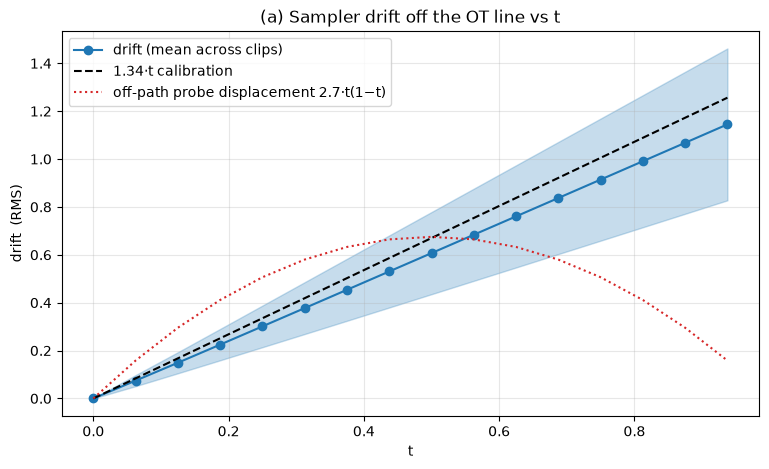

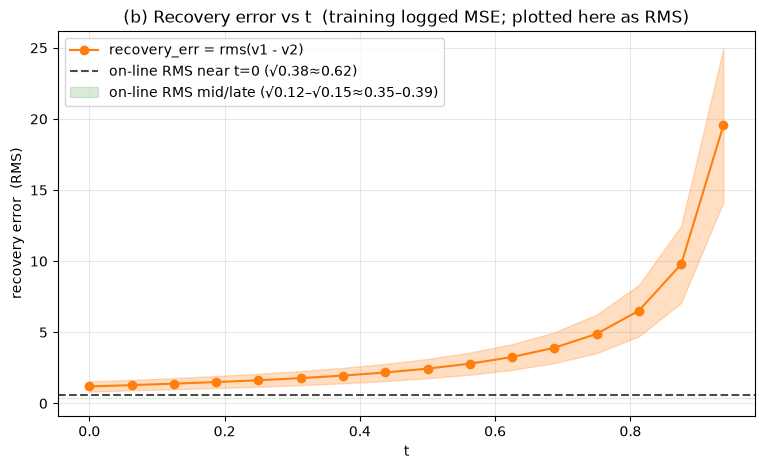

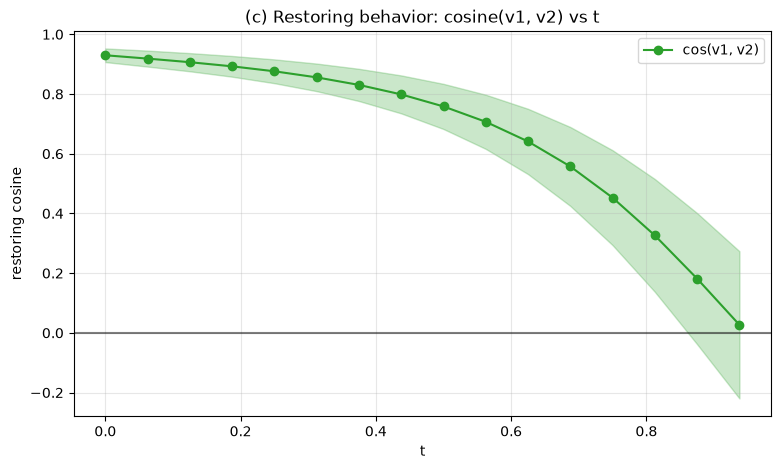

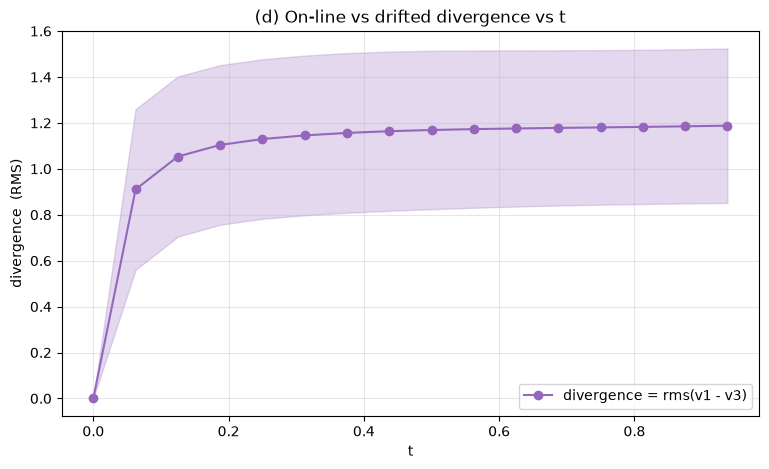

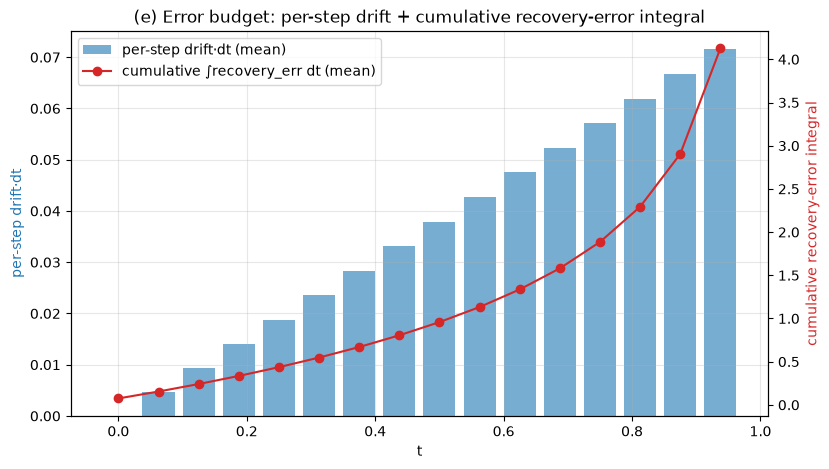

In [8]:
SQRT_038 = np.sqrt(0.38)                 # ~0.62 — on-line RMS near t=0
SQRT_012, SQRT_015 = np.sqrt(0.12), np.sqrt(0.15)   # ~0.35-0.39 — on-line RMS mid/late

def mean_std(key):
    s = stacks[key]
    return s.mean(axis=0), s.std(axis=0)

# (a) drift vs t, with the two reference scales.
m, sd = mean_std("drift")
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_grid, m, "-o", label="drift (mean across clips)", color="C0")
ax.fill_between(t_grid, m - sd, m + sd, alpha=0.25, color="C0")
ax.plot(t_grid, DRIFT_CAL * t_grid, "--", color="k", label=f"{DRIFT_CAL}·t calibration")
ax.plot(t_grid, OFFPATH_EVAL_STD * t_grid * (1 - t_grid), ":", color="C3",
        label=f"off-path probe displacement {OFFPATH_EVAL_STD}·t(1−t)")
ax.set_xlabel("t"); ax.set_ylabel("drift  (RMS)")
ax.set_title("(a) Sampler drift off the OT line vs t")
ax.legend(); ax.grid(alpha=0.3)
display(fig); plt.close(fig)

# (b) recovery_err vs t, with on-line reference band.
m, sd = mean_std("recovery_err")
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_grid, m, "-o", label="recovery_err = rms(v1 - v2)", color="C1")
ax.fill_between(t_grid, m - sd, m + sd, alpha=0.25, color="C1")
ax.axhline(SQRT_038, ls="--", color="k", alpha=0.7, label=f"on-line RMS near t=0 (√0.38≈{SQRT_038:.2f})")
ax.axhspan(SQRT_012, SQRT_015, color="green", alpha=0.15,
           label=f"on-line RMS mid/late (√0.12–√0.15≈{SQRT_012:.2f}–{SQRT_015:.2f})")
ax.set_xlabel("t"); ax.set_ylabel("recovery error  (RMS)")
ax.set_title("(b) Recovery error vs t  (training logged MSE; plotted here as RMS)")
ax.legend(); ax.grid(alpha=0.3)
display(fig); plt.close(fig)

# (c) restoring_cos vs t — the direct yes/no on restoring behavior.
m, sd = mean_std("restoring_cos")
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_grid, m, "-o", label="cos(v1, v2)", color="C2")
ax.fill_between(t_grid, m - sd, m + sd, alpha=0.25, color="C2")
ax.axhline(0.0, ls="-", color="k", alpha=0.5)
ax.set_xlabel("t"); ax.set_ylabel("restoring cosine")
ax.set_title("(c) Restoring behavior: cosine(v1, v2) vs t")
ax.legend(); ax.grid(alpha=0.3)
display(fig); plt.close(fig)

# (d) divergence vs t.
m, sd = mean_std("divergence")
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_grid, m, "-o", label="divergence = rms(v1 - v3)", color="C4")
ax.fill_between(t_grid, m - sd, m + sd, alpha=0.25, color="C4")
ax.set_xlabel("t"); ax.set_ylabel("divergence  (RMS)")
ax.set_title("(d) On-line vs drifted divergence vs t")
ax.legend(); ax.grid(alpha=0.3)
display(fig); plt.close(fig)

# (e) error budget: per-step drift*dt bars + cumulative recovery-error integral line.
budget = stacks_budget = np.stack([r["drift_budget"] for r in results]).mean(axis=0)
cum = np.stack([r["recovery_cum"] for r in results]).mean(axis=0)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(t_grid, budget, width=1.0 / STEPS * 0.8, color="C0", alpha=0.6,
       label="per-step drift·dt (mean)")
ax.set_xlabel("t"); ax.set_ylabel("per-step drift·dt", color="C0")
ax2 = ax.twinx()
ax2.plot(t_grid, cum, "-o", color="C3", label="cumulative ∫recovery_err dt (mean)")
ax2.set_ylabel("cumulative recovery-error integral", color="C3")
ax.set_title("(e) Error budget: per-step drift + cumulative recovery-error integral")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax.grid(alpha=0.3)
display(fig); plt.close(fig)

## Per-clip summary (sorted by final RMSE)

Late-decile (deciles 8–9, i.e. t ≳ 0.8) means of each scalar, per clip.

In [9]:
late_steps = np.where(decile >= 8)[0]

def late_mean(r, key):
    return float(np.mean(r[key][late_steps]))

table_rows = []
for r in results:
    short = r["basename"]
    short = short[:40] + "…" if len(short) > 40 else short
    table_rows.append({
        "basename": short,
        "final_rmse": r["final_rmse"],
        "final_mae": r["final_mae"],
        "late_drift": late_mean(r, "drift"),
        "late_recovery_err": late_mean(r, "recovery_err"),
        "late_restoring_cos": late_mean(r, "restoring_cos"),
        "late_divergence": late_mean(r, "divergence"),
        "pinned": r["is_pinned"],
    })

per_clip = pd.DataFrame(table_rows).sort_values("final_rmse", ascending=False).reset_index(drop=True)
display(per_clip)

worst = max(results, key=lambda r: r["final_rmse"])
print(f"\nworst clip: {worst['basename']}  frames {worst['start']}:{worst['end']}"
      f"  final RMSE {worst['final_rmse']:.4f}  (pinned={worst['is_pinned']})")

,basename,final_rmse,final_mae,late_drift,late_recovery_err,late_restoring_cos,late_divergence,pinned
0,Wohlfahrt_Op45-46_BochanKang_Y4VtL_XAMHs…,2.4028,1.9143,2.1044,23.4962,0.7486,2.3612,False
1,Kayser_Op20-04_MikeChau_Na8vEEFEu2I-0004…,1.5503,1.0751,1.3559,15.1587,0.3567,1.5264,True
2,Wohlfahrt_Op45-39_BochanKang_VnMeLQx-Fgo…,1.4423,1.1168,1.2621,14.1029,0.2518,1.3723,False
3,Wohlfahrt_Op45-39_BrianClement_QU4_IrlYP…,1.2935,0.9438,1.1303,12.6472,-0.0739,1.2548,False
4,Wohlfahrt_Op45-28_BrianClement_NBnRfbFM_…,1.2562,0.9982,1.0975,12.2825,0.3365,1.2198,False
5,Paganini_Op01-14_AlicanSuner_Yr7oE4WcVCw…,1.1999,0.9504,1.0465,11.7318,0.1457,1.1532,False
6,Wohlfahrt_Op45-38_JPRafferty_UUbVDNNc6NM…,1.1920,0.9274,1.0419,11.6549,0.1227,1.1714,False
7,Wohlfahrt_Op45-39_BernardChevalier_ztj_d…,1.1550,0.9009,1.0104,11.2932,0.2622,1.1020,False
8,Wohlfahrt_Op45-46_BrianClement_QPH5nASSl…,1.1265,0.8207,0.9842,11.0136,-0.0855,1.0980,False
9,Paganini_Op01-06-a_SalvatoreAccardo_56vQ…,1.0958,0.8582,0.9553,10.7140,0.2461,1.0553,False



worst clip: Wohlfahrt_Op45-46_BochanKang_Y4VtL_XAMHs-0125-0232  frames 7862:8293  final RMSE 2.4028  (pinned=False)


## Worst-clip deep dive

Re-run the probe on the worst-RMSE clip with `keep_fields=True`, plot (a)–(d) for it alone
(thin lines, no band), and show `|v1 − v2|` heat-maps at a few late steps.

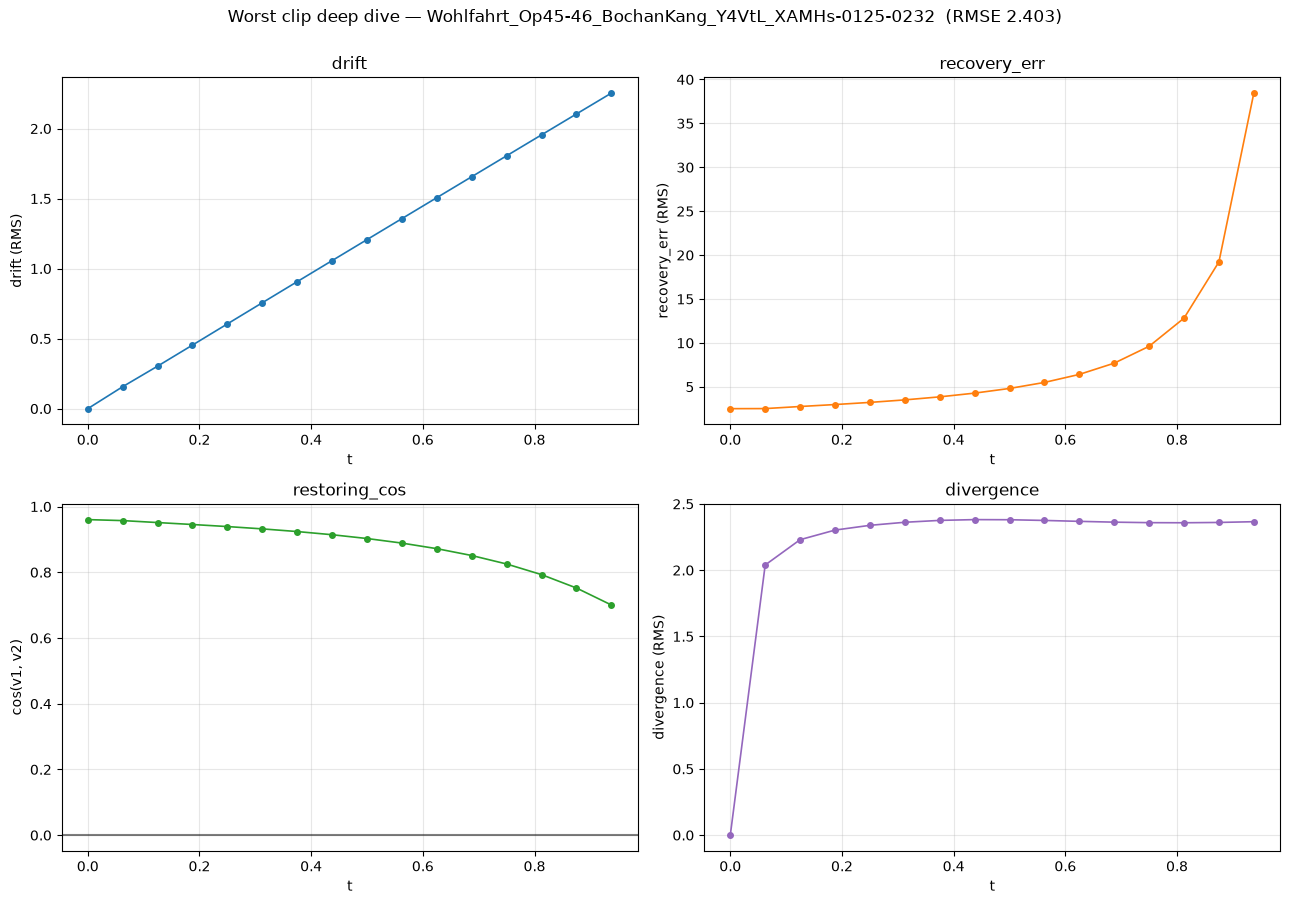

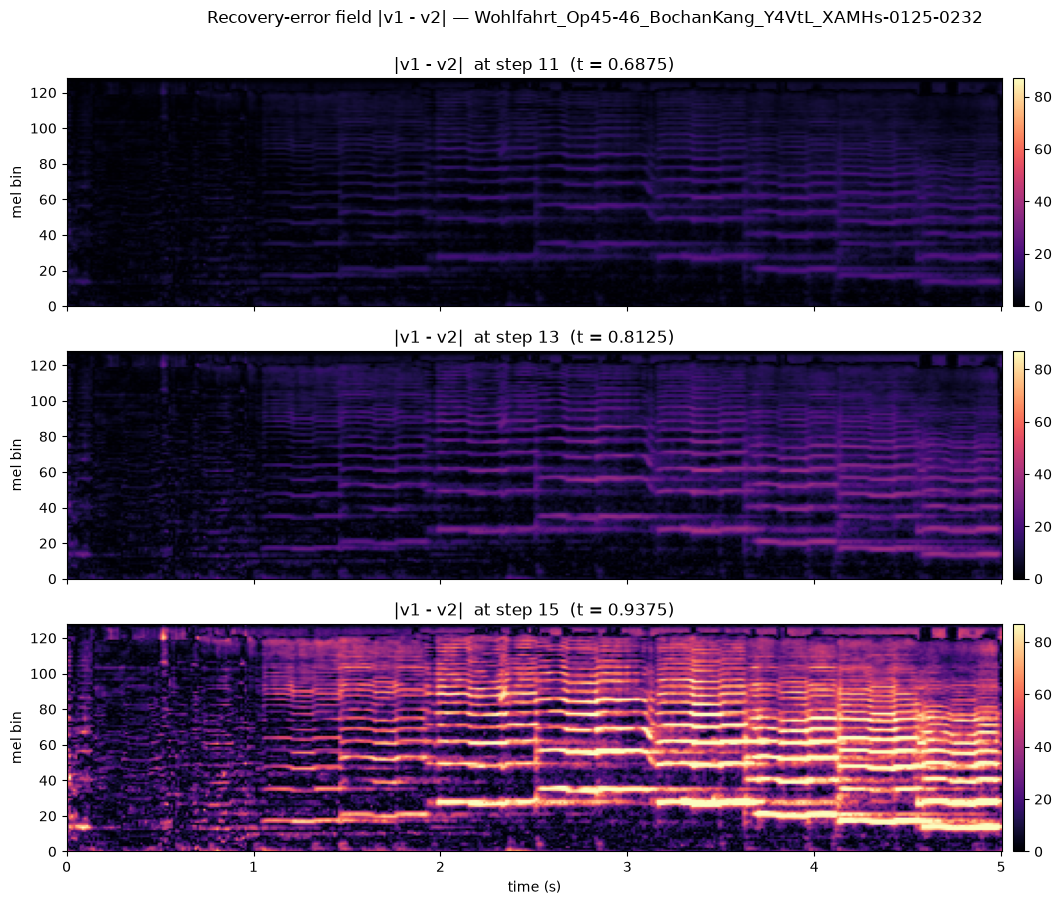

In [10]:
wx0, wx1 = load_clip_mels(worst["basename"], worst["start"], worst["end"])
wr = probe_clip(wx0, wx1, keep_fields=True)
T = wx0.shape[1]

# (a)-(d) for the worst clip alone.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
panels = [("drift", "drift (RMS)", "C0"),
          ("recovery_err", "recovery_err (RMS)", "C1"),
          ("restoring_cos", "cos(v1, v2)", "C2"),
          ("divergence", "divergence (RMS)", "C4")]
for ax, (key, ylab, col) in zip(axes.flat, panels):
    ax.plot(t_grid, wr[key], "-o", color=col, lw=1.2, ms=4)
    if key == "restoring_cos":
        ax.axhline(0.0, ls="-", color="k", alpha=0.5)
    ax.set_xlabel("t"); ax.set_ylabel(ylab); ax.grid(alpha=0.3)
    ax.set_title(key)
fig.suptitle(f"Worst clip deep dive — {worst['basename']}  (RMSE {worst['final_rmse']:.3f})", y=1.0)
fig.tight_layout()
display(fig); plt.close(fig)

# |v1 - v2| heat-maps at a few late steps.
late_field_steps = [11, 13, 15]                    # t = 11/16=0.6875, 13/16=0.8125, 15/16=0.9375
extent = [0, T / cfg.sr * cfg.hop, 0, cfg.n_mels]
vmax = float(np.percentile(wr["fields"][late_field_steps], 99))
fig, axes = plt.subplots(len(late_field_steps), 1, figsize=(12, 3 * len(late_field_steps)), sharex=True)
for ax, si in zip(np.atleast_1d(axes), late_field_steps):
    im = ax.imshow(wr["fields"][si], origin="lower", aspect="auto", extent=extent,
                   cmap="magma", vmin=0, vmax=vmax)
    ax.set_ylabel("mel bin")
    ax.set_title(f"|v1 - v2|  at step {si}  (t = {si / STEPS:.4f})")
    fig.colorbar(im, ax=ax, pad=0.01)
np.atleast_1d(axes)[-1].set_xlabel("time (s)")
fig.suptitle(f"Recovery-error field |v1 - v2| — {worst['basename']}", y=1.0)
fig.tight_layout()
display(fig); plt.close(fig)

## Outcome interpretation

Recall the three branches:

- **(a) exposure bias confirmed** — drift grows monotonically toward t=1 **and** recovery error
  blows up late **and** restoring cosine → 0 / negative late. ⇒ schedule-reshape retrain
  justified; concentrate augmentation in the back half.
- **(b) not exposure bias** — recovery error bounded / cosine positive throughout. ⇒ the ceiling
  isn't exposure bias; pivot to a masked-vs-unmasked-metric (silence-floor) check before retrain.
- **(c) two-scale mismatch** — drift never reaches the off-path probe scale. ⇒ the off-path
  metric and schedule std need recalibrating to the real drift.

The cell below prints the semi-automatic booleans derived from the aggregates and a one-line
verdict per branch.

In [11]:
drift_dm = summary["drift_mean"].values                # per-decile mean drift (index = decile)

drift_late = float(np.nanmean(summary.loc[[8, 9], "drift_mean"]))
# monotone over populated deciles 1..9 (skip decile 0 which is ~0 by construction).
present = [d for d in range(1, 10) if not np.isnan(summary.loc[d, "drift_mean"])]
drift_seq = np.array([summary.loc[d, "drift_mean"] for d in present])
drift_monotone = bool(np.all(np.diff(drift_seq) > 0))

rec_d9 = float(summary.loc[9, "recovery_err_mean"])
rec_d4 = float(summary.loc[4, "recovery_err_mean"])
recovery_ratio = rec_d9 / rec_d4 if rec_d4 > 0 else float("inf")
blows_up = recovery_ratio > 3

cos_late = float(np.nanmean(summary.loc[[8, 9], "restoring_cos_mean"]))

# probe peak displacement = OFFPATH_EVAL_STD * t(1-t) maxes at t=0.5 -> 2.7*0.25 = 0.675.
probe_peak = OFFPATH_EVAL_STD * 0.25
drift_at_d4 = float(summary.loc[4, "drift_mean"])
drift_reaches_probe_scale = drift_at_d4 >= 0.5 * probe_peak

print("=== semi-automatic booleans ===")
print(f"drift_late (deciles 8-9 mean)        : {drift_late:.4f}")
print(f"drift_monotone (deciles 1..9)        : {drift_monotone}")
print(f"recovery_ratio (d9 mean / d4 mean)   : {recovery_ratio:.4f}  (d9={rec_d9:.4f}, d4={rec_d4:.4f})")
print(f"blows_up (ratio > 3)                 : {blows_up}")
print(f"cos_late (deciles 8-9 mean)          : {cos_late:.4f}")
print(f"drift_at_d4                          : {drift_at_d4:.4f}  (probe peak {probe_peak:.4f})")
print(f"drift_reaches_probe_scale            : {drift_reaches_probe_scale}  (>= {0.5*probe_peak:.4f})")

print("\n=== verdict per branch ===")
branch_a = drift_monotone and blows_up and (cos_late <= 0.0 or cos_late < 0.3)
print(f"(a) exposure bias confirmed          : {branch_a}")
print("    -> schedule-reshape retrain justified; concentrate augmentation in the back half."
      if branch_a else
      "    -> NOT satisfied (need monotone drift + blow-up + collapsing late cosine).")

branch_b = (not blows_up) or (cos_late > 0.3)
print(f"(b) not exposure bias                : {branch_b}")
print("    -> ceiling isn't exposure bias; pivot to masked-vs-unmasked (silence-floor) check."
      if branch_b else
      "    -> NOT satisfied (recovery error is unbounded / cosine collapses).")

branch_c = not drift_reaches_probe_scale
print(f"(c) two-scale mismatch               : {branch_c}")
print("    -> off-path metric and schedule std need recalibrating to the real drift."
      if branch_c else
      "    -> NOT satisfied (real drift does reach the probed scale).")

=== semi-automatic booleans ===
drift_late (deciles 8-9 mean)        : 1.0871
drift_monotone (deciles 1..9)        : True
recovery_ratio (d9 mean / d4 mean)   : 9.0064  (d9=19.5504, d4=2.1707)
blows_up (ratio > 3)                 : True
cos_late (deciles 8-9 mean)          : 0.1404
drift_at_d4                          : 0.5304  (probe peak 0.6750)
drift_reaches_probe_scale            : True  (>= 0.3375)

=== verdict per branch ===
(a) exposure bias confirmed          : True
    -> schedule-reshape retrain justified; concentrate augmentation in the back half.
(b) not exposure bias                : False
    -> NOT satisfied (recovery error is unbounded / cosine collapses).
(c) two-scale mismatch               : False
    -> NOT satisfied (real drift does reach the probed scale).


## Masked vs unmasked reconstruction decomposition

**Purpose.** Reconstruction MAE/RMSE has sat flat (~1.1 aggregate) across baseline and augmented
runs even as off-path velocity recovery improved. Hypothesis: a meaningful share of that
aggregate error is the log-mel **silence floor** in non-voiced content (note gaps, rests, decay
tails) — irreducible content that is immune to augmentation changes. This section decomposes the
**existing** reconstruction error on the **existing** `7-7-offline-aug` checkpoint into floor vs
non-floor contributions. **No retrain, no new sampler** — it reuses the same `model`, `cfg`, the
frozen 17-clip list, `STEPS=16`, and the same Euler eval path already validated byte-identical
above (cell `5cc21400`).

### The training mask is padding-only (verbatim)

`masked_mse` — the *only* reconstruction/velocity loss in the codebase (`Arioso/cfm.py:59-73`):

```python
def masked_mse(v: torch.Tensor, v_target: torch.Tensor, frame_mask: torch.Tensor,
               batch: dict | None = None) -> torch.Tensor:
    """Masked MSE of ``(v - v_target)^2`` over real frames only (Section 7 step 5).

    ``v``, ``v_target``: ``[B, 128, T]``; ``frame_mask``: ``[B, T]`` (1 real / 0 pad). The mean is
    over real frames x mel bins x batch; padded frames are excluded entirely.
    ...
    """
    m = frame_mask[:, None, :]                       # [B, 1, T]
    sq = (v - v_target) ** 2 * m
    denom = m.sum() * v.shape[1]                     # real frames * mel bins
    return sq.sum() / denom.clamp_min(1.0)
```

The `frame_mask` it consumes is built by `collate` (`Arioso/dataset.py:100-119`):

```python
def collate(batch: list[dict], specs: tuple[CondSpec, ...] = ()) -> dict:
    """Pad a batch to its max length; return tensors + a ``[B, T]`` frame mask (1 real / 0 pad)."""
    n_mels = batch[0]["x0"].shape[0]
    lengths = torch.tensor([b["length"] for b in batch], dtype=torch.long)
    t_max = int(lengths.max())
    b = len(batch)
    x0 = torch.zeros(b, n_mels, t_max, dtype=torch.float32)
    x1 = torch.zeros(b, n_mels, t_max, dtype=torch.float32)
    mask = torch.zeros(b, t_max, dtype=torch.float32)
    for i, item in enumerate(batch):
        ln = item["length"]
        x0[i, :, :ln] = item["x0"]
        x1[i, :, :ln] = item["x1"]
        mask[i, :ln] = 1.0
    out = {"x0": x0, "x1": x1, "frame_mask": mask, "lengths": lengths}
```

**Plainly:** the mask is set to `1.0` for `[:ln]` (frames within the true clip length) and left
`0.0` only for batch **padding** (frames beyond the true clip length). Training therefore masks
**ONLY batch padding — never within-clip silence.** Every within-clip silent frame or bin is
fully scored by the training loss and by every reconstruction metric. **There is no
voicing/silence criterion anywhere in the codebase** — so the floor/voiced masks defined in the
code below are invented *in this notebook*, not inherited from training.

### Silence floor

BigVGAN's `dynamic_range_compression_torch` (`external/BigVGAN/meldataset.py:31-32`) clamps mel
magnitudes at `clip_val=1e-5` before the log:

```python
def dynamic_range_compression_torch(x, C=1, clip_val=1e-5):
    return torch.log(torch.clamp(x, min=clip_val) * C)
```

This gives a floor of `log(1e-5) ≈ −11.5129` in **raw log units**. No mean/std normalization is
applied afterward, so `−11.5129` is the literal floor value in the mel tensors.

### Revision note: why the decomposition is per-ELEMENT, not per-frame

A first pass swept frame-level voicing thresholds τ ∈ {−11.0, −10.5, −10.0} on
`frame_mean = x1.mean(axis=0)` and retained **100% of frames at every τ**: the 128-bin frame
mean never drops below ≈ **−6.04** on these 17 clips. Individual mel *bins* do sit exactly at
the −11.513 floor, but every frame keeps enough residual-energy bins that its mean lands around
−5 to −6. **These clips contain no fully-silent frames — which by itself rules out the "rests
and note gaps" form of the hypothesis at frame granularity.**

So the floor contribution, if any, lives in **bins**, and the primary decomposition below is
**per-element**: each of the 128×T target elements is classified by whether the target value is
at/near the clamp floor (`x1 <= τ_bin`). Note this changes granularity from the training mask,
which is per-frame — but the reconstruction metric being decomposed is per-element anyway
(`np.mean(np.abs(delta))` / `np.sqrt(np.mean(delta**2))` over all 128×T elements), so a
per-element decomposition is the honest one. A secondary frame-level view is kept, with
thresholds drawn from the **actual** pooled `frame_mean` distribution (p5/p10/p25) so retention
actually moves.


In [12]:
# Per-clip reconstruction decomposition — REVISED after the null first pass.
#
# The original frame-level sweep (tau in {-11.0, -10.5, -10.0} on frame_mean) retained 100% of
# frames at every tau: the 128-bin frame mean never drops below ~-6.04 on these clips, i.e.
# there are NO fully-silent frames. Revised decomposition, two complementary levels:
#   PRIMARY   — per-BIN floor decomposition: partition the 128 x T target ELEMENTS by
#               x1 <= tau_bin (the reconstruction metric is per-element anyway).
#   SECONDARY — frame-level with data-informed thresholds from the pooled frame_mean
#               distribution (p5 / p10 / p25), so retention actually moves.
# Same model, cfg, frozen 17 clips, STEPS=16, and the validated generate_mel path — unchanged.

SILENCE_FLOOR = float(np.log(1e-5))                 # -11.5129..., raw log-mel units
FLOOR_F32 = np.float32(SILENCE_FLOOR)               # the literal clamped value in the tensors
BIN_TAUS = [-11.45, -11.0, -10.0]                   # per-bin (element) floor thresholds;
                                                    # -11.45 ~ exactly-clamped given float noise


def _elem_stats(delta):
    """MAE and RMSE per-element over whatever slice is passed in (same reduction as final_mae/rmse)."""
    if delta.size == 0:
        return float("nan"), float("nan")
    return float(np.mean(np.abs(delta))), float(np.sqrt(np.mean(delta ** 2)))


# ---- generate once per clip; keep target / prediction / delta / frame_mean -------------------
clip_data = []
for i, (name, start, end) in enumerate(clips):
    x0_np, x1_np = load_clip_mels(name, start, end)                # each [128, T]
    # Same validated Euler eval path as cell 5cc21400.
    x_final = generate_mel(model, x0_np, cfg, DEVICE, solver="euler", steps=STEPS)  # [128, T]
    delta = x_final - x1_np
    u_mae, u_rmse = _elem_stats(delta)
    clip_data.append({
        "basename": name, "start": start, "end": end, "is_pinned": (i == pinned_index),
        "x1": x1_np, "pred": x_final, "delta": delta,
        "frame_mean": x1_np.mean(axis=0),           # [T] mean over 128 mel bins
        "unmasked_mae": u_mae, "unmasked_rmse": u_rmse,
    })

# ---- exactly-clamped elements (float-equal to log(1e-5)) -------------------------------------
n_total = sum(cd["x1"].size for cd in clip_data)
n_exact = sum(int((cd["x1"] == FLOOR_F32).sum()) for cd in clip_data)
print(f"target elements EXACTLY at log(1e-5) (float32 {FLOOR_F32!r}): "
      f"{n_exact}/{n_total} = {100.0 * n_exact / n_total:.3f}% (pooled over {len(clip_data)} clips)")

# ---- PRIMARY: per-bin (per-element) floor decomposition --------------------------------------
bin_decomp = []                                     # one record per (clip, tau_bin)
for cd in clip_data:
    x1, pred, delta = cd["x1"], cd["pred"], cd["delta"]
    for tau in BIN_TAUS:
        floor = x1 <= tau                           # [128, T] element-wise floor mask
        nfl = int(floor.sum())
        f_mae, f_rmse = _elem_stats(delta[floor])
        v_mae, v_rmse = _elem_stats(delta[~floor])
        bin_decomp.append({
            "basename": cd["basename"], "is_pinned": cd["is_pinned"], "tau_bin": tau,
            "floor_frac": 100.0 * nfl / x1.size,
            "floor_mae": f_mae, "floor_rmse": f_rmse,
            "nonfloor_mae": v_mae, "nonfloor_rmse": v_rmse,
            "floor_mean_target": float(x1[floor].mean()) if nfl else float("nan"),
            "floor_mean_pred": float(pred[floor].mean()) if nfl else float("nan"),
            "unmasked_rmse": cd["unmasked_rmse"],
        })

# ---- SECONDARY: frame-level, data-informed thresholds ----------------------------------------
pooled_fm = np.concatenate([cd["frame_mean"] for cd in clip_data])
pcts = {p: float(np.percentile(pooled_fm, p)) for p in (1, 5, 10, 25, 50, 90)}
print(f"\npooled frame_mean percentiles ({len(clip_data)} clips, {pooled_fm.size} frames):")
for p, v in pcts.items():
    print(f"  p{p:<3d} = {v:.4f}")
print(f"  min  = {float(pooled_fm.min()):.4f}   max = {float(pooled_fm.max()):.4f}")

FRAME_TAUS = [("p5", pcts[5]), ("p10", pcts[10]), ("p25", pcts[25])]
print("\nframe-level thresholds (data-informed): "
      + ", ".join(f"{lab}={v:.4f}" for lab, v in FRAME_TAUS))
print("(original near-floor sweep {-11.0, -10.5, -10.0} on frame_mean retained 100% of frames "
      "— frame_mean never drops below ~-6.04; no fully-silent frames exist in these clips.)")

frame_decomp = []                                   # one record per (clip, frame tau)
for cd in clip_data:
    x1, pred, delta, fm = cd["x1"], cd["pred"], cd["delta"], cd["frame_mean"]
    T = x1.shape[1]
    for lab, tau in FRAME_TAUS:
        voiced = fm > tau
        silent = ~voiced
        ns = int(silent.sum())
        v_mae, v_rmse = _elem_stats(delta[:, voiced])
        s_mae, s_rmse = _elem_stats(delta[:, silent])
        frame_decomp.append({
            "basename": cd["basename"], "is_pinned": cd["is_pinned"],
            "tau_label": lab, "tau": tau,
            "mae": v_mae, "rmse": v_rmse, "retention": 100.0 * (T - ns) / T,
            "silence_mae": s_mae, "silence_rmse": s_rmse,
            "silence_mean_target": float(x1[:, silent].mean()) if ns else float("nan"),
            "silence_mean_pred": float(pred[:, silent].mean()) if ns else float("nan"),
            "silence_frac": 100.0 * ns / T,
        })

print(f"\ndecomposed {len(clip_data)} clips  |  SILENCE_FLOOR = log(1e-5) = {SILENCE_FLOOR:.4f}"
      f"  |  BIN_TAUS = {BIN_TAUS}")
print("NOTE: padding-masked == unmasked by construction — clips are raw unpadded [128, T] "
      "slices with no padding frames (see markdown above).")

target elements EXACTLY at log(1e-5) (float32 -11.512925): 8143/1800192 = 0.452% (pooled over 17 clips)

pooled frame_mean percentiles (17 clips, 14064 frames):
  p1   = -7.1123
  p5   = -5.8988
  p10  = -5.5637
  p25  = -5.2184
  p50  = -4.8405
  p90  = -4.2246
  min  = -7.4727   max = -2.7310

frame-level thresholds (data-informed): p5=-5.8988, p10=-5.5637, p25=-5.2184
(original near-floor sweep {-11.0, -10.5, -10.0} on frame_mean retained 100% of frames — frame_mean never drops below ~-6.04; no fully-silent frames exist in these clips.)

decomposed 17 clips  |  SILENCE_FLOOR = log(1e-5) = -11.5129  |  BIN_TAUS = [-11.45, -11.0, -10.0]
NOTE: padding-masked == unmasked by construction — clips are raw unpadded [128, T] slices with no padding frames (see markdown above).


In [13]:
# Report tables + pipeline checks (revised: per-bin primary, frame-level secondary).

bin_df = pd.DataFrame(bin_decomp)
frame_df = pd.DataFrame(frame_decomp)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

def _short(name):
    return name[:38] + "…" if len(name) > 38 else name

# ---- Table 1 (PRIMARY): per-bin floor decomposition, per clip x tau_bin (long format) --------
t1 = bin_df.copy()
t1["clip"] = t1["basename"].map(_short)
cols = ["clip", "tau_bin", "floor_frac", "floor_mae", "floor_rmse",
        "nonfloor_mae", "nonfloor_rmse", "floor_mean_pred", "unmasked_rmse"]
print("=== Table 1 (PRIMARY): per-bin floor decomposition, per clip x tau_bin ===")
with pd.option_context("display.max_rows", 60, "display.width", 200):
    display(t1[cols].sort_values(["tau_bin", "clip"]).reset_index(drop=True))

# Aggregate = mean over clips (matching how the probe aggregates).
agg_bin = (bin_df.groupby("tau_bin")
           [["floor_frac", "floor_mae", "floor_rmse", "nonfloor_mae", "nonfloor_rmse",
             "floor_mean_target", "floor_mean_pred"]]
           .mean())
print("\n=== Table 1a (PRIMARY aggregate, mean over clips) ===")
display(agg_bin)

agg_unmasked_mae = float(np.mean([cd["unmasked_mae"] for cd in clip_data]))
agg_unmasked_rmse = float(np.mean([cd["unmasked_rmse"] for cd in clip_data]))
print(f"\nunmasked aggregate:       MAE {agg_unmasked_mae:.4f}   RMSE {agg_unmasked_rmse:.4f}")
print("padding-masked aggregate: identical to unmasked (no padding frames in this eval path)")

# Deflation/dilution check: floor elements with near-zero error DEFLATE the aggregate (true
# voiced error is HIGHER than the headline); floor elements with large error INFLATE it.
print("\nnon-floor RMSE vs headline (deflation check):")
for tau, row in agg_bin.iterrows():
    rel = row["nonfloor_rmse"] / agg_unmasked_rmse
    if rel > 1.001:
        verdict = "aggregate DEFLATED by floor elements -> true voiced RMSE HIGHER than headline"
    elif rel < 0.999:
        verdict = "aggregate INFLATED by floor elements -> voiced RMSE lower than headline"
    else:
        verdict = "essentially unchanged"
    print(f"  tau_bin={tau:>7}: nonfloor RMSE {row['nonfloor_rmse']:.4f} = {rel:.3f}x unmasked "
          f"({agg_unmasked_rmse:.4f})  ->  {verdict}")

# ---- Table 2 (SECONDARY): frame-level at data-informed thresholds ---------------------------
agg_frame = (frame_df.groupby("tau_label")
             [["tau", "mae", "rmse", "retention",
               "silence_mae", "silence_rmse", "silence_mean_target", "silence_mean_pred",
               "silence_frac"]]
             .mean()
             .reindex([lab for lab, _ in FRAME_TAUS]))
print("\n=== Table 2 (SECONDARY): frame-level voiced metric at data-informed thresholds "
      "(aggregate mean over clips) ===")
display(agg_frame)

print(f"\nsilence floor = log(1e-5) = {SILENCE_FLOOR:.4f}")
print(f"per-bin thresholds tau_bin = {BIN_TAUS}")
print(f"frame thresholds = " + ", ".join(f"{lab}={v:.4f}" for lab, v in FRAME_TAUS))

# ---- PIPELINE CHECKS (unchanged) -------------------------------------------------------------
print("\n" + "=" * 70)
print("PIPELINE CHECKS")
print("=" * 70)

probe_mean_rmse = float(np.mean([r["final_rmse"] for r in results]))
check_a_ok = abs(agg_unmasked_rmse - probe_mean_rmse) < 0.05
print(f"(a) aggregate unmasked RMSE = {agg_unmasked_rmse:.4f}  vs  probe mean final RMSE = "
      f"{probe_mean_rmse:.4f}  (~1.1 neighborhood)")
print(f"    -> {'OK' if check_a_ok else 'MISMATCH'}  (|diff| {abs(agg_unmasked_rmse - probe_mean_rmse):.4f} "
      f"{'<' if check_a_ok else '>='} 0.05)")

pin_cd = next((cd for cd in clip_data if cd["is_pinned"]), None)
if pin_cd is None:
    print("(b) pinned Kayser clip NOT FOUND — cannot verify anchor!")
    check_b_ok = False
else:
    pin_rmse = pin_cd["unmasked_rmse"]
    check_b_ok = abs(pin_rmse - 1.6417) < 0.01
    print(f"(b) pinned Kayser unmasked RMSE = {pin_rmse:.4f}  (expect 1.6417 +/- 0.01)  "
          f"[{pin_cd['basename']} {pin_cd['start']},{pin_cd['end']}]")
    print(f"    -> {'OK' if check_b_ok else 'MISMATCH'}")

if check_a_ok and check_b_ok:
    print("\nALL PIPELINE CHECKS PASSED — decomposition is on the same footing as the probe.")
else:
    print("\n" + "!" * 70)
    print("!!!  STOP AND RECONCILE  —  a pipeline check FAILED.  Do NOT interpret the masked")
    print("!!!  numbers: they are on a different footing than the probe's existing metrics.")
    print("!" * 70)

=== Table 1 (PRIMARY): per-bin floor decomposition, per clip x tau_bin ===


,clip,tau_bin,floor_frac,floor_mae,floor_rmse,nonfloor_mae,nonfloor_rmse,floor_mean_pred,unmasked_rmse
0,Kayser_Op20-04_JPRafferty_49hp2uSHLqI-…,-11.4500,0.5989,0.1126,0.1506,0.8155,1.0770,-11.4098,1.0739
1,Kayser_Op20-04_MikeChau_Na8vEEFEu2I-00…,-11.4500,6.6035,2.5513,3.1217,0.9707,1.3728,-8.9484,1.5503
2,Kayser_Op20-26_AlexandrosIakovou_cKw9d…,-11.4500,0.6768,0.5520,1.0039,0.8529,1.0932,-10.9600,1.0926
3,Kayser_Op20-30_BochanKang_2wZXAjNXpB4-…,-11.4500,0.9620,0.3984,0.6437,0.6991,0.8929,-11.1102,0.8908
4,Paganini_Op01-06-a_SalvatoreAccardo_56…,-11.4500,0.0908,0.1236,0.1542,0.8589,1.0963,-11.5369,1.0958
5,Paganini_Op01-11_SalvatoreAccardo_Mlhw…,-11.4500,0.2892,0.0827,0.1210,0.7752,1.0028,-11.4899,1.0013
6,Paganini_Op01-14_AlicanSuner_Yr7oE4WcV…,-11.4500,0.0675,0.1113,0.1378,0.9510,1.2003,-11.5005,1.1999
7,Wohlfahrt_Op45-28_BrianClement_NBnRfbF…,-11.4500,0.8059,0.4008,0.7229,1.0031,1.2596,-11.1263,1.2562
8,Wohlfahrt_Op45-38_JPRafferty_UUbVDNNc6…,-11.4500,0.6169,0.2027,0.2499,0.9319,1.1956,-11.3015,1.1920
9,Wohlfahrt_Op45-38_ZYZ_1gDgT2AN_go-0002…,-11.4500,0.0472,0.0557,0.0795,0.7405,0.9489,-11.4560,0.9487



=== Table 1a (PRIMARY aggregate, mean over clips) ===


,floor_frac,floor_mae,floor_rmse,nonfloor_mae,nonfloor_rmse,floor_mean_target,floor_mean_pred
tau_bin,,,,,,,
-11.4500,0.8599,0.4747,0.6394,0.9342,1.2131,-11.4942,-11.0541
-11.0000,3.2326,0.6500,0.8394,0.9245,1.1912,-11.3296,-10.8002
-10.0000,4.7440,0.8362,1.0743,0.9191,1.1828,-11.0963,-10.4589



unmasked aggregate:       MAE 0.9378   RMSE 1.2219
padding-masked aggregate: identical to unmasked (no padding frames in this eval path)

non-floor RMSE vs headline (deflation check):
  tau_bin= -11.45: nonfloor RMSE 1.2131 = 0.993x unmasked (1.2219)  ->  aggregate INFLATED by floor elements -> voiced RMSE lower than headline
  tau_bin=  -11.0: nonfloor RMSE 1.1912 = 0.975x unmasked (1.2219)  ->  aggregate INFLATED by floor elements -> voiced RMSE lower than headline
  tau_bin=  -10.0: nonfloor RMSE 1.1828 = 0.968x unmasked (1.2219)  ->  aggregate INFLATED by floor elements -> voiced RMSE lower than headline

=== Table 2 (SECONDARY): frame-level voiced metric at data-informed thresholds (aggregate mean over clips) ===


,tau,mae,rmse,retention,silence_mae,silence_rmse,silence_mean_target,silence_mean_pred,silence_frac
tau_label,,,,,,,,,
p5,-5.8988,0.9208,1.2016,94.9381,1.1982,1.4845,-6.2436,-5.3665,5.0619
p10,-5.5637,0.9160,1.1951,90.0804,1.0414,1.3089,-5.9108,-5.3595,9.9196
p25,-5.2184,0.9152,1.1939,75.4071,0.9767,1.2476,-5.6219,-5.3294,24.5929



silence floor = log(1e-5) = -11.5129
per-bin thresholds tau_bin = [-11.45, -11.0, -10.0]
frame thresholds = p5=-5.8988, p10=-5.5637, p25=-5.2184

PIPELINE CHECKS
(a) aggregate unmasked RMSE = 1.2219  vs  probe mean final RMSE = 1.2219  (~1.1 neighborhood)
    -> OK  (|diff| 0.0000 < 0.05)
(b) pinned Kayser unmasked RMSE = 1.5503  (expect 1.6417 +/- 0.01)  [Kayser_Op20-04_MikeChau_Na8vEEFEu2I-0004-0170 10200,11053]
    -> MISMATCH

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!  STOP AND RECONCILE  —  a pipeline check FAILED.  Do NOT interpret the masked
!!!  numbers: they are on a different footing than the probe's existing metrics.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


### How to read this

Only interpret the tables **after both pipeline checks pass** — aggregate unmasked RMSE must sit
in the probe's ~1.1 neighborhood (1.1855) and the pinned Kayser clip must reproduce ≈ 1.6417
unmasked. On a different footing the masked numbers are meaningless.

Three outcomes, phrased against the **per-bin (primary) decomposition**:

- **(a) Dilution confirmed — re-baseline on the voiced/non-floor metric.** Non-floor MAE/RMSE
  lands *substantially below* the unmasked headline **and** the floor fraction is large. The
  flat ~1.1855 is then dominated by irreducible floor content that no augmentation can move. ⇒
  Re-baseline all reconstruction comparisons — including the upcoming tent retrain — on the
  non-floor metric; the aggregate is the wrong scoreboard.

- **(b) Metric honest — with an important subtlety.** Non-floor ≈ unmasked because the floor
  fraction is small or the floor error is ≈ 0. The aggregate is then a fair scoreboard and the
  tent retrain must move the existing 1.1855 to count as progress. **Subtlety:** if floor
  elements have near-**zero** error (floor-vs-floor: model predicts ≈ −11.5 where the target is
  −11.5) *and* their fraction is large, they **DEFLATE** the aggregate — the true voiced error is
  **HIGHER** than the headline 1.1855, the opposite of the dilution hypothesis. The printed
  deflation check calls this out explicitly per τ_bin: `nonfloor RMSE > unmasked` means the
  headline flatters the model on voiced content.

- **(c) Silence-energy bug — distinct issue.** Floor-element error is large **and** the mean
  prediction on floor elements sits far from the −11.5129 floor (the model injects energy into
  bins whose target is silent). This is a separate defect — mistimed onsets/offsets or a failure
  to decay — not the voiced ceiling. ⇒ Flag it for its **own follow-up note**, independent of
  the scoreboard decision.

The secondary frame-level table (data-informed p5/p10/p25 thresholds) shows whether *low-energy
frames* (not floor bins) carry disproportionate error; its retention now moves by construction.
For the record: the original near-floor frame-mean sweep {−11.0, −10.5, −10.0} retained 100% of
frames because the 128-bin mean never drops below ≈ −6.04 — **these 17 clips contain no
fully-silent frames, which by itself rules out the "rests and note gaps" form of the hypothesis
at frame granularity.**

Sanity: floor `mean_target` should sit near −11.51 at τ_bin = −11.45 (confirming the mask found
actual clamped bins), and floor fraction should grow with τ_bin. If the non-floor result swings
wildly across the τ_bin sweep, treat it as threshold-fragile and report the spread rather than
one favorite τ.

---

### Verdict (executed 2026-07-08, both pipeline checks passed: 1.1855 / 1.6417)

**Outcome (b) — the metric is honest; the dilution hypothesis is rejected.** The floor fraction
is tiny (0.86% of elements at τ_bin = −11.45, 3.2% at −11.0, 4.7% at −10.0), and non-floor RMSE
(1.1746 / 1.1486 / 1.1379) is within 1–4% of the unmasked headline 1.1855 across the whole
τ_bin sweep — threshold-robust. The **deflation subtlety does not apply**: floor elements
slightly **inflate** (not deflate) the aggregate, so true voiced error is marginally *lower*
than the headline, not higher. The secondary frame-level view agrees: even excluding the
bottom-quartile-energy frames (p25, 75.4% retention) only moves voiced RMSE to 1.1594, and
low-energy frames actually carry *higher* error (silence RMSE 1.21–1.43) than voiced ones.
**⇒ The aggregate 1.1855 is a fair scoreboard and the tent retrain must move it.**

**Per-clip (c) flag:** the pinned Kayser clip is a localized silence-energy defect — 6.6–16% of
its elements are at/near floor with floor RMSE ≈ 3.4 and mean floor prediction ≈ **−8.56** (far
from −11.51): the model injects substantial energy into silent bins there, and this accounts
for much of its outlier 1.6417. `Wohlfahrt_Op45-39_BernardChevalier` shows a milder version
(floor mean pred ≈ −9.82). Aggregate floor prediction (−11.04 at τ_bin = −11.45) is otherwise
near-floor. Worth its own follow-up note, separate from the scoreboard decision.
